# Network Analysis

Sieci interakcji użytkowników w czterech muzycznych subredditach. Każdy węzeł to użytkownik, a każda krawędź oznacza, że jeden użytkownik odpowiedział innemu.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
from collections import Counter
from itertools import combinations
import plotly.graph_objects as go
from community import community_louvain

Path('../outputs/figures').mkdir(parents=True, exist_ok=True)

df = pd.read_csv('../data/processed/all_subreddits_sample.csv')
print(df.shape)
df[['author', 'parent_id', 'link_id', 'subreddit']].head()

(2544183, 10)


,author,parent_id,link_id,subreddit
0,Moron_on_Oxy-,t3_fglr4p,t3_fglr4p,hiphopheads
1,superchingonguey,t1_fk5o56t,t3_fgnnun,hiphopheads
2,Aniceguy96,t1_fk5mi66,t3_fglr4p,hiphopheads
3,Sushieatinbeast,t3_fgihaz,t3_fgihaz,hiphopheads
4,DocterJohnSmith,t1_fk5o548,t3_fglr4p,hiphopheads


## 1. Budowa sieci

In [2]:
replies = df[df['parent_id'].str.startswith('t1_', na=False)].copy()
replies['parent_comment_id'] = replies['parent_id'].str[3:]

edges = replies.merge(
    df[['comment_id', 'author']].rename(columns={'author': 'parent_author'}),
    left_on='parent_comment_id',
    right_on='comment_id',
    how='inner'
)
edges = edges[edges['author'] != edges['parent_author']]

print(f'Znaleziono {len(edges)} krawedzi')
edges[['subreddit', 'author', 'parent_author']].head(10)

Znaleziono 1540868 krawedzi


,subreddit,author,parent_author
0,hiphopheads,Vadermaulkylo,Moron_on_Oxy-
1,hiphopheads,dylwaybake,OH-PEACHY
2,hiphopheads,Aniceguy96,Moron_on_Oxy-
3,hiphopheads,Moron_on_Oxy-,Vadermaulkylo
4,hiphopheads,dadouks,Aniceguy96
5,hiphopheads,undercoverlurk,lndw20
6,hiphopheads,Moron_on_Oxy-,Aniceguy96
7,hiphopheads,Aniceguy96,dadouks
8,hiphopheads,Vadermaulkylo,Moron_on_Oxy-
9,hiphopheads,Aniceguy96,Moron_on_Oxy-


In [3]:
graphs = {}
for sub, group in edges.groupby('subreddit'):
    G = nx.DiGraph()
    for _, row in group.iterrows():
        G.add_edge(row['author'], row['parent_author'])
    graphs[sub] = G
    print(f'r/{sub}: {G.number_of_nodes()} wezlow, {G.number_of_edges()} krawedzi')

r/Metal: 11046 wezlow, 45632 krawedzi
r/hiphopheads: 83286 wezlow, 619011 krawedzi
r/indieheads: 32213 wezlow, 143111 krawedzi
r/popheads: 27179 wezlow, 317932 krawedzi


## 2. Podstawowe metryki

In [4]:
metrics = []
for sub, G in graphs.items():
    G_und = G.to_undirected()
    degrees = [d for _, d in G_und.degree()]
    metrics.append({
        'subreddit':  sub,
        'nodes':      G.number_of_nodes(),
        'edges':      G.number_of_edges(),
        'density':    round(nx.density(G_und), 4),
        'avg_degree': round(np.mean(degrees), 2),
        'max_degree': max(degrees),
    })

pd.DataFrame(metrics).set_index('subreddit')

,nodes,edges,density,avg_degree,max_degree
subreddit,,,,,
Metal,11046,45632,0.0006,6.37,441
hiphopheads,83286,619011,0.0001,11.96,4331
indieheads,32213,143111,0.0002,6.97,963
popheads,27179,317932,0.0007,18.55,2210


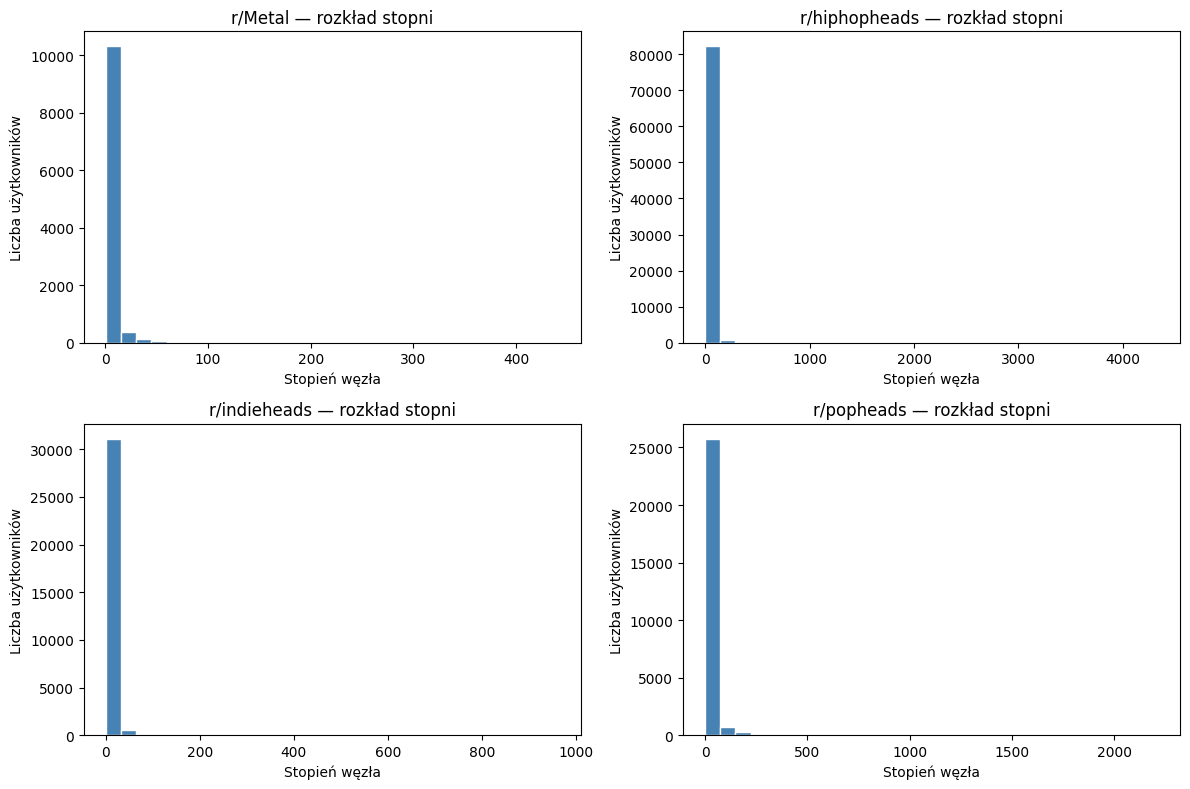

In [5]:
# rozklad stopni
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, (sub, G) in enumerate(graphs.items()):
    degrees = [d for _, d in G.to_undirected().degree()]
    axes[i].hist(degrees, bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'r/{sub} — rozkład stopni')
    axes[i].set_xlabel('Stopień węzła')
    axes[i].set_ylabel('Liczba użytkowników')
plt.tight_layout()
plt.savefig('../outputs/figures/degree_distribution.png', dpi=150)
plt.show()

## 3. Centralność

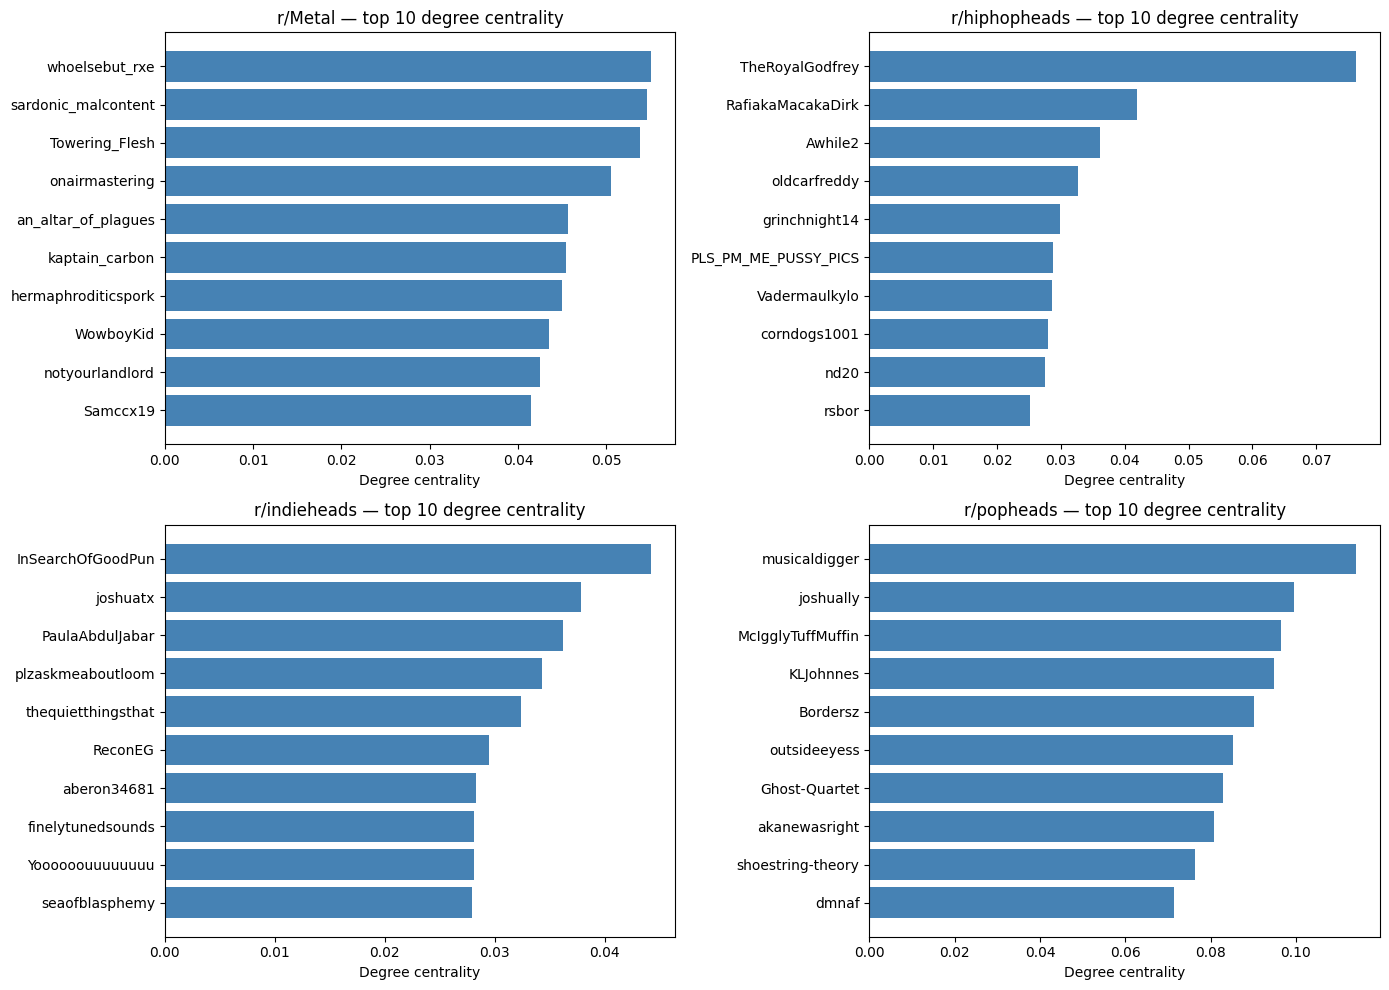

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, (sub, G) in enumerate(graphs.items()):
    degree_cent = nx.degree_centrality(G)
    top = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:10]
    users  = [u for u, _ in top][::-1]
    values = [v for _, v in top][::-1]
    axes[i].barh(users, values, color='steelblue')
    axes[i].set_title(f'r/{sub} — top 10 degree centrality')
    axes[i].set_xlabel('Degree centrality')
plt.tight_layout()
plt.savefig('../outputs/figures/degree_centrality.png', dpi=150)
plt.show()

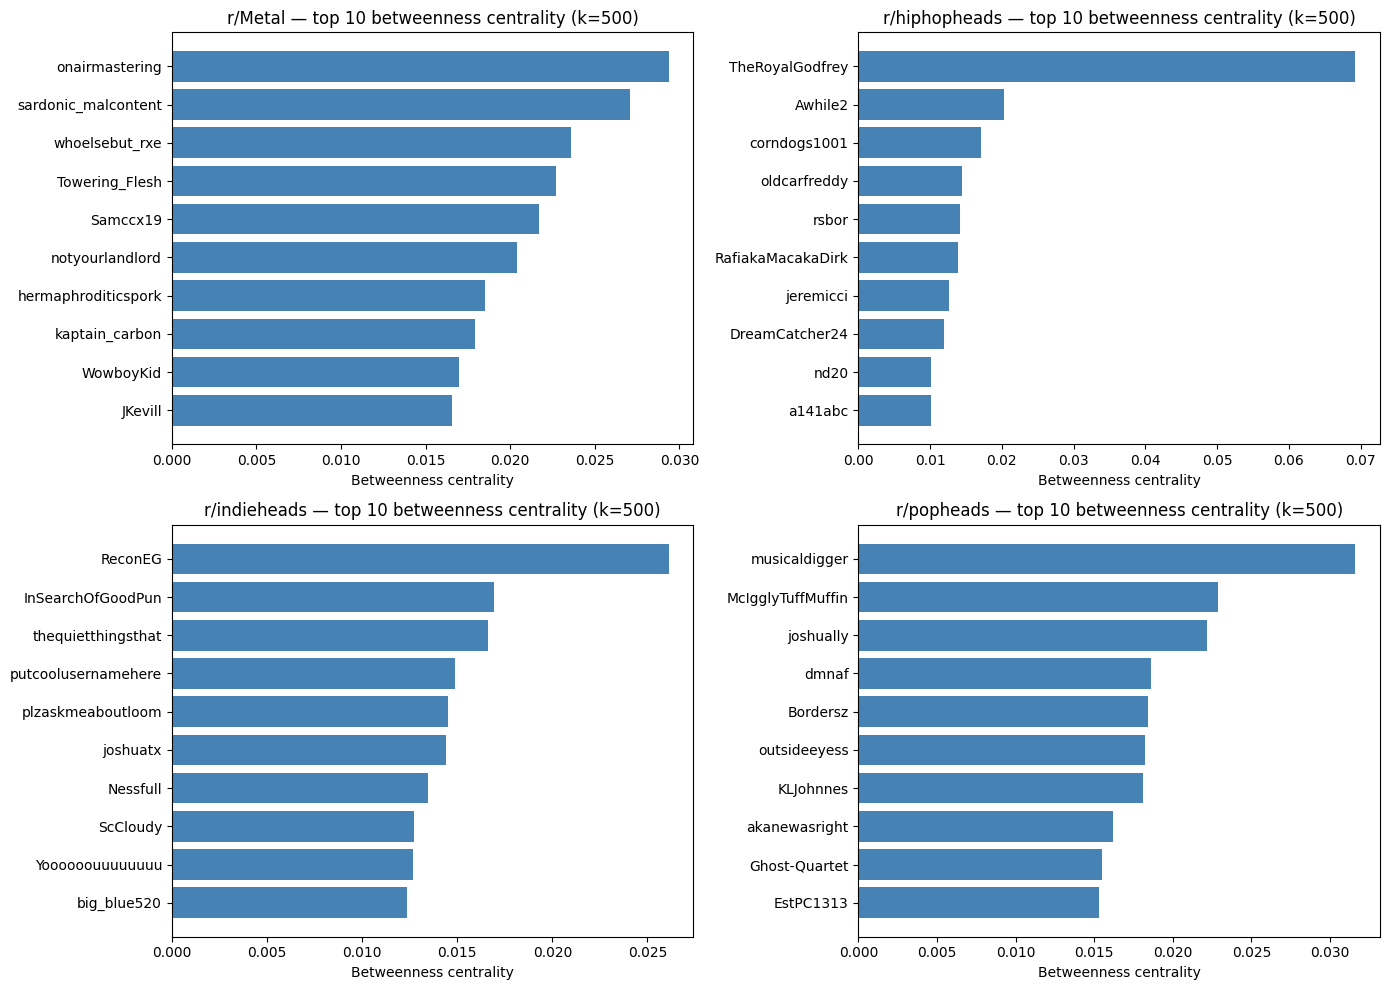

In [7]:
# betweenness centrality — k=500 to przyblizenie, znacznie szybsze niz pelne obliczenia
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, (sub, G) in enumerate(graphs.items()):
    between_cent = nx.betweenness_centrality(G, k=500)
    top = sorted(between_cent.items(), key=lambda x: x[1], reverse=True)[:10]
    users  = [u for u, _ in top][::-1]
    values = [v for _, v in top][::-1]
    axes[i].barh(users, values, color='steelblue')
    axes[i].set_title(f'r/{sub} — top 10 betweenness centrality (k=500)')
    axes[i].set_xlabel('Betweenness centrality')
plt.tight_layout()
plt.savefig('../outputs/figures/betweenness_centrality.png', dpi=150)
plt.show()

## 4. Wykrywanie społeczności (Louvain)

In [8]:
community_stats = []
for sub, G in graphs.items():
    G_und = G.to_undirected()
    partition = community_louvain.best_partition(G_und)
    num_communities = len(set(partition.values()))
    modularity = community_louvain.modularity(partition, G_und)
    largest = max(Counter(partition.values()).values())
    community_stats.append({
        'subreddit':         sub,
        'communities':       num_communities,
        'modularity':        round(modularity, 3),
        'largest_community': largest,
    })
    nx.set_node_attributes(G, partition, 'community')

pd.DataFrame(community_stats).set_index('subreddit')

,communities,modularity,largest_community
subreddit,,,
Metal,391,0.397,1843
hiphopheads,815,0.302,17571
indieheads,791,0.428,4815
popheads,350,0.199,7203


## 5. Wizualizacja sieci (2D)

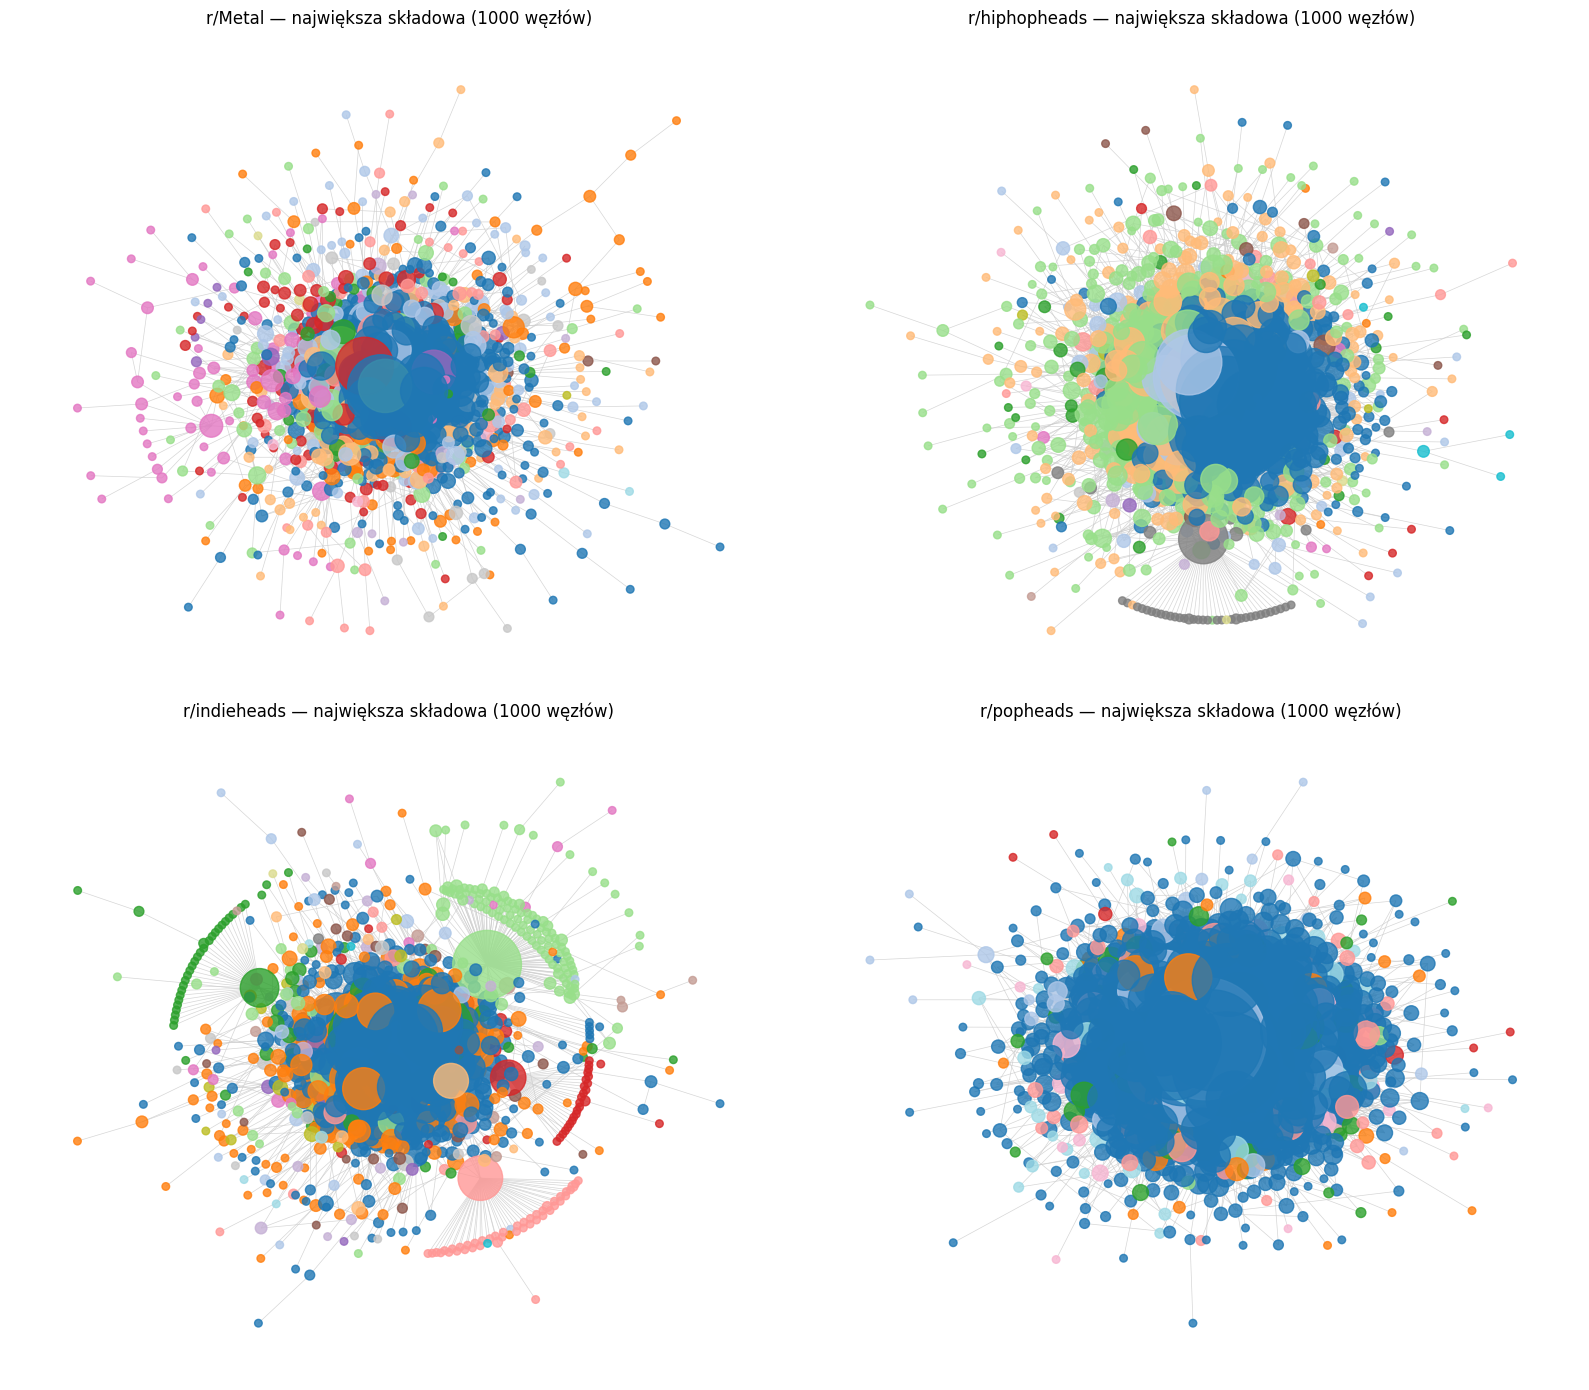

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()
for i, (sub, G) in enumerate(graphs.items()):
    ax = axes[i]
    G_und = G.to_undirected()
    largest_cc = max(nx.connected_components(G_und), key=len)
    G_sub = G_und.subgraph(largest_cc)
    if len(G_sub) > 100:
        G_sub = G_sub.subgraph(list(G_sub.nodes())[:100])
    pos = nx.kamada_kawai_layout(G_sub)
    communities = nx.get_node_attributes(G, 'community')
    node_colors = [communities.get(n, 0) for n in G_sub.nodes()]
    degrees = dict(G_sub.degree())
    node_sizes = [degrees[n] * 20 + 10 for n in G_sub.nodes()]
    nx.draw_networkx(G_sub, pos=pos, ax=ax, with_labels=False,
                     node_color=node_colors, node_size=node_sizes,
                     edge_color='#cccccc', width=0.5, cmap=plt.cm.tab20, alpha=0.8)
    ax.set_title(f'r/{sub} — największa składowa ({len(G_sub)} węzłów)')
    ax.axis('off')
plt.tight_layout()
plt.savefig('../outputs/figures/network_communities.png', dpi=150)
plt.show()

## 6. Wizualizacja 3D (interaktywna)

In [ ]:
for sub, G in graphs.items():
    G_und = G.to_undirected()
    largest_cc = max(nx.connected_components(G_und), key=len)
    G_sub = G_und.subgraph(largest_cc)
    if len(G_sub) > 10:
        top_nodes = [n for n, _ in sorted(G_sub.degree(), key=lambda x: x[1], reverse=True)[:10]]
        G_sub = G_sub.subgraph(top_nodes)
    pos = nx.spring_layout(G_sub, dim=3, seed=42, k=1.5)
    communities = nx.get_node_attributes(G, 'community')
    degrees = dict(G_sub.degree())
    edge_x, edge_y, edge_z = [], [], []
    for u, v in G_sub.edges():
        x0, y0, z0 = pos[u]
        x1, y1, z1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]
        edge_z += [z0, z1, None]
    edge_trace = go.Scatter3d(x=edge_x, y=edge_y, z=edge_z, mode='lines',
                               line=dict(color='#aaaaaa', width=1), hoverinfo='none')
    node_trace = go.Scatter3d(
        x=[pos[n][0] for n in G_sub.nodes()],
        y=[pos[n][1] for n in G_sub.nodes()],
        z=[pos[n][2] for n in G_sub.nodes()],
        mode='markers+text',
        marker=dict(size=[degrees[n] * 2 + 5 for n in G_sub.nodes()],
                    color=[communities.get(n, 0) for n in G_sub.nodes()],
                    colorscale='Viridis', opacity=0.9),
        text=list(G_sub.nodes()), textposition='top center',
        textfont=dict(size=8), hoverinfo='text'
    )
    fig = go.Figure(
        data=[edge_trace, node_trace],
        layout=go.Layout(
            title=f'r/{sub} — top 10 użytkowników (sieć 3D)', showlegend=False,
            scene=dict(xaxis=dict(showticklabels=False, title=''),
                       yaxis=dict(showticklabels=False, title=''),
                       zaxis=dict(showticklabels=False, title=''), bgcolor='white'),
            paper_bgcolor='white'
        )
    )
    out_path = f'../outputs/network_3d_{sub}.html'
    fig.write_html(out_path)
    print(f'Zapisano -> {out_path}')

Zapisano -> ../outputs/network_3d_Metal.html
Zapisano -> ../outputs/network_3d_hiphopheads.html
Zapisano -> ../outputs/network_3d_indieheads.html
Zapisano -> ../outputs/network_3d_popheads.html


## 7. Cross-subreddit — wspólni użytkownicy

In [11]:
sub_users = df.groupby('subreddit')['author'].apply(set)
subreddits = list(sub_users.index)

print('Wspólni użytkownicy między subredditami:\n')
for s1, s2 in combinations(subreddits, 2):
    overlap = sub_users[s1] & sub_users[s2]
    pct_s1 = len(overlap) / len(sub_users[s1]) * 100
    pct_s2 = len(overlap) / len(sub_users[s2]) * 100
    print(f'  {s1} & {s2}: {len(overlap)} uzytkownikow  ({pct_s1:.1f}% z {s1}, {pct_s2:.1f}% z {s2})')

Wspólni użytkownicy między subredditami:

  Metal & hiphopheads: 678 uzytkownikow  (4.0% z Metal, 0.6% z hiphopheads)
  Metal & indieheads: 486 uzytkownikow  (2.9% z Metal, 0.9% z indieheads)
  Metal & popheads: 151 uzytkownikow  (0.9% z Metal, 0.4% z popheads)
  hiphopheads & indieheads: 5842 uzytkownikow  (5.3% z hiphopheads, 11.3% z indieheads)
  hiphopheads & popheads: 4904 uzytkownikow  (4.5% z hiphopheads, 13.2% z popheads)
  indieheads & popheads: 3396 uzytkownikow  (6.6% z indieheads, 9.2% z popheads)


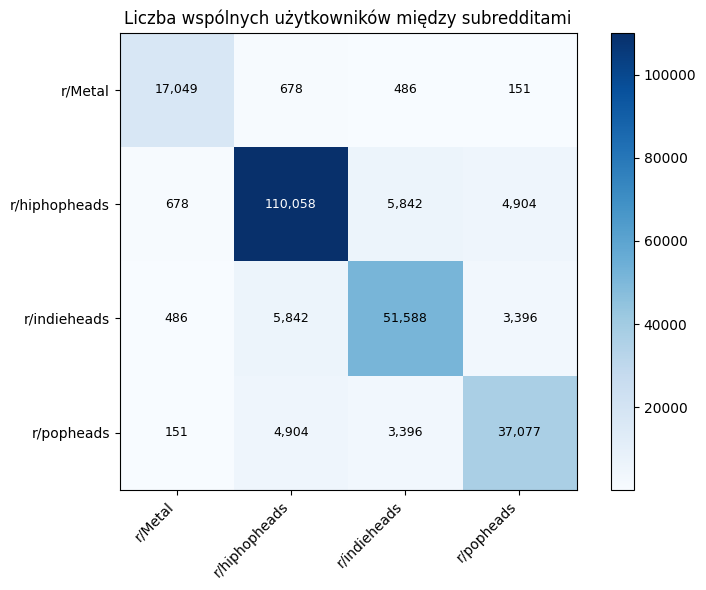

In [12]:
# heatmapa przeciec
n = len(subreddits)
matrix = np.zeros((n, n))
for i, s1 in enumerate(subreddits):
    for j, s2 in enumerate(subreddits):
        matrix[i][j] = len(sub_users[s1]) if i == j else len(sub_users[s1] & sub_users[s2])

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(matrix, cmap='Blues')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([f'r/{s}' for s in subreddits], rotation=45, ha='right')
ax.set_yticklabels([f'r/{s}' for s in subreddits])
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{int(matrix[i][j]):,}', ha='center', va='center',
                fontsize=9, color='white' if matrix[i][j] > matrix.max() * 0.5 else 'black')
ax.set_title('Liczba wspólnych użytkowników między subredditami')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('../outputs/figures/cross_subreddit_heatmap.png', dpi=150)
plt.show()

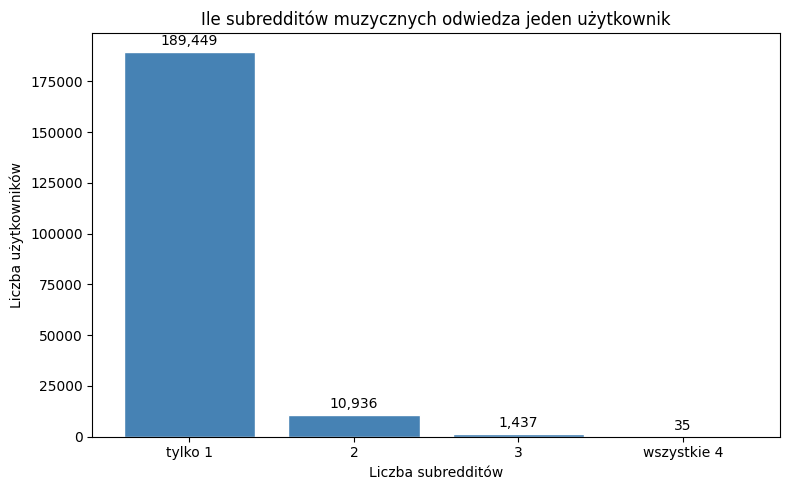

Uzytkownicy aktywni we wszystkich 4 subredditach: 35
Top 10 wedlug lacznej liczby komentarzy:
author
MorrisFae             2205
CaptainOvbious        1714
Ktulusanders          1179
riddhishb              688
OLD_GREGG420           684
lanternsinthesky       423
boner_4ever            394
MangoMiasma            292
______________-__-     267
TheHavesHaveThot       199
Name: comment_id, dtype: int64


In [13]:
# ile subredditow odwiedza kazdy uzytkownik
user_sub_count = df.groupby('author')['subreddit'].nunique()
distribution = user_sub_count.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(distribution.index, distribution.values, color='steelblue', edgecolor='white')
ax.set_title('Ile subredditów muzycznych odwiedza jeden użytkownik')
ax.set_xlabel('Liczba subredditów')
ax.set_ylabel('Liczba użytkowników')
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['tylko 1', '2', '3', 'wszystkie 4'])
for bar, val in zip(bars, distribution.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + distribution.max() * 0.01,
            f'{val:,}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/figures/user_subreddit_distribution.png', dpi=150)
plt.show()

# uzytkownicy we wszystkich 4 subredditach
all_four = sub_users[subreddits[0]]
for s in subreddits[1:]:
    all_four = all_four & sub_users[s]
print(f'Uzytkownicy aktywni we wszystkich 4 subredditach: {len(all_four)}')
if len(all_four) > 0:
    counts = df[df['author'].isin(all_four)].groupby('author')['comment_id'].count()
    print('Top 10 wedlug lacznej liczby komentarzy:')
    print(counts.nlargest(10))

## 8. Influencerzy

In [14]:
# influence score = srednia z 3 metryk: degree centrality, betweenness centrality, liczba komentarzy
all_influence = []

for sub, G in graphs.items():
    degree_cent   = nx.degree_centrality(G)
    betw_cent     = nx.betweenness_centrality(G, k=500)
    comment_count = df[df['subreddit'] == sub]['author'].value_counts()

    influence_df = pd.DataFrame({
        'degree_centrality':      pd.Series(degree_cent),
        'betweenness_centrality': pd.Series(betw_cent),
        'comment_count':          comment_count,
    }).dropna()

    for col in ['degree_centrality', 'betweenness_centrality', 'comment_count']:
        col_max = influence_df[col].max()
        if col_max > 0:
            influence_df[f'{col}_norm'] = influence_df[col] / col_max

    influence_df['influence_score'] = (
        influence_df['degree_centrality_norm'] +
        influence_df['betweenness_centrality_norm'] +
        influence_df['comment_count_norm']
    ) / 3

    influence_df['subreddit'] = sub
    all_influence.append(influence_df.nlargest(10, 'influence_score'))

    print(f'r/{sub}:')
    print(influence_df.nlargest(10, 'influence_score')[['degree_centrality', 'betweenness_centrality', 'comment_count', 'influence_score']].round(4))
    print()

r/Metal:
                     degree_centrality  betweenness_centrality  comment_count  \
sardonic_malcontent             0.0546                  0.0291            849   
onairmastering                  0.0505                  0.0267            995   
whoelsebut_rxe                  0.0550                  0.0246            942   
Towering_Flesh                  0.0538                  0.0237            895   
hermaphroditicspork             0.0450                  0.0235            731   
an_altar_of_plagues             0.0456                  0.0216            723   
kaptain_carbon                  0.0455                  0.0152            841   
WowboyKid                       0.0435                  0.0137            766   
notyourlandlord                 0.0425                  0.0178            604   
ThePiperMan                     0.0402                  0.0172            603   

                     influence_score  
sardonic_malcontent           0.9483  
onairmastering       

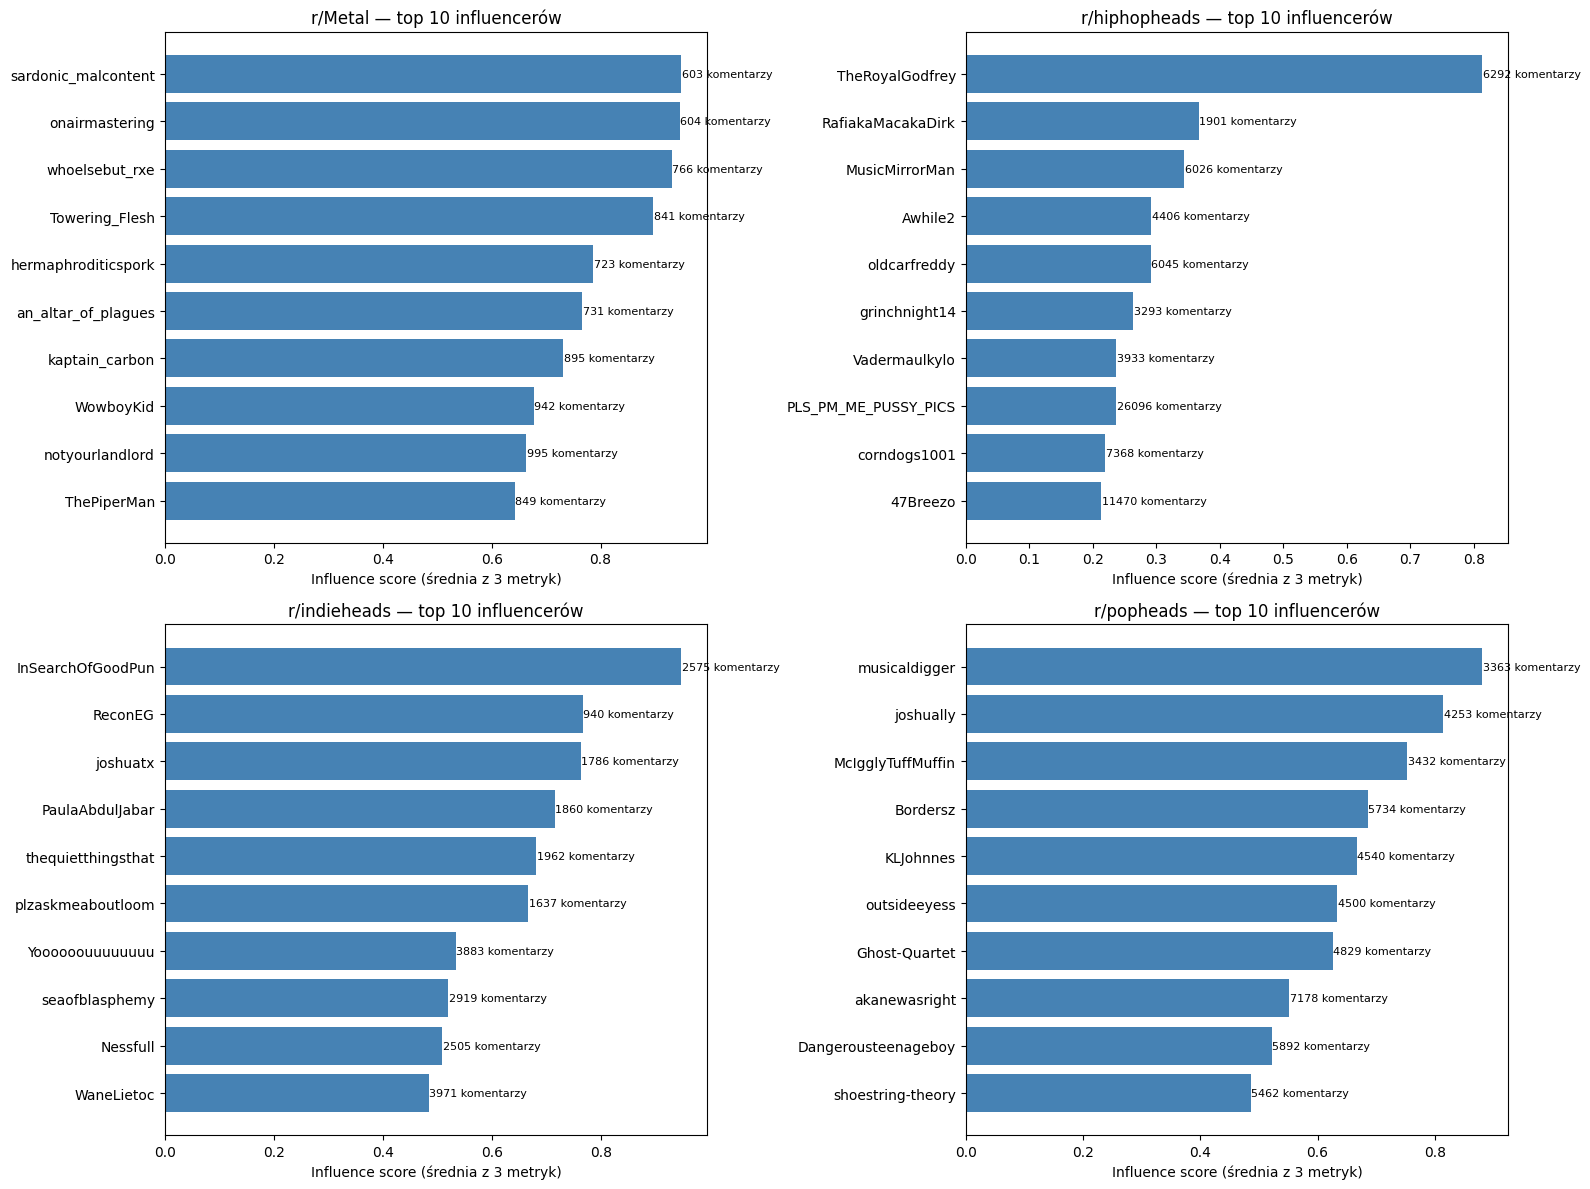

In [15]:
# wykres top 10 influencerow per subreddit
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for i, (sub, G) in enumerate(graphs.items()):
    top = all_influence[i].nlargest(10, 'influence_score')
    users  = list(top.index)[::-1]
    scores = list(top['influence_score'])[::-1]
    bars = axes[i].barh(users, scores, color='steelblue')
    axes[i].set_title(f'r/{sub} — top 10 influencerów')
    axes[i].set_xlabel('Influence score (średnia z 3 metryk)')
    for bar, user in zip(bars, users[::-1]):
        count = int(top.loc[user, 'comment_count'])
        axes[i].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                     f'{count} komentarzy', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/figures/influencers.png', dpi=150)
plt.show()

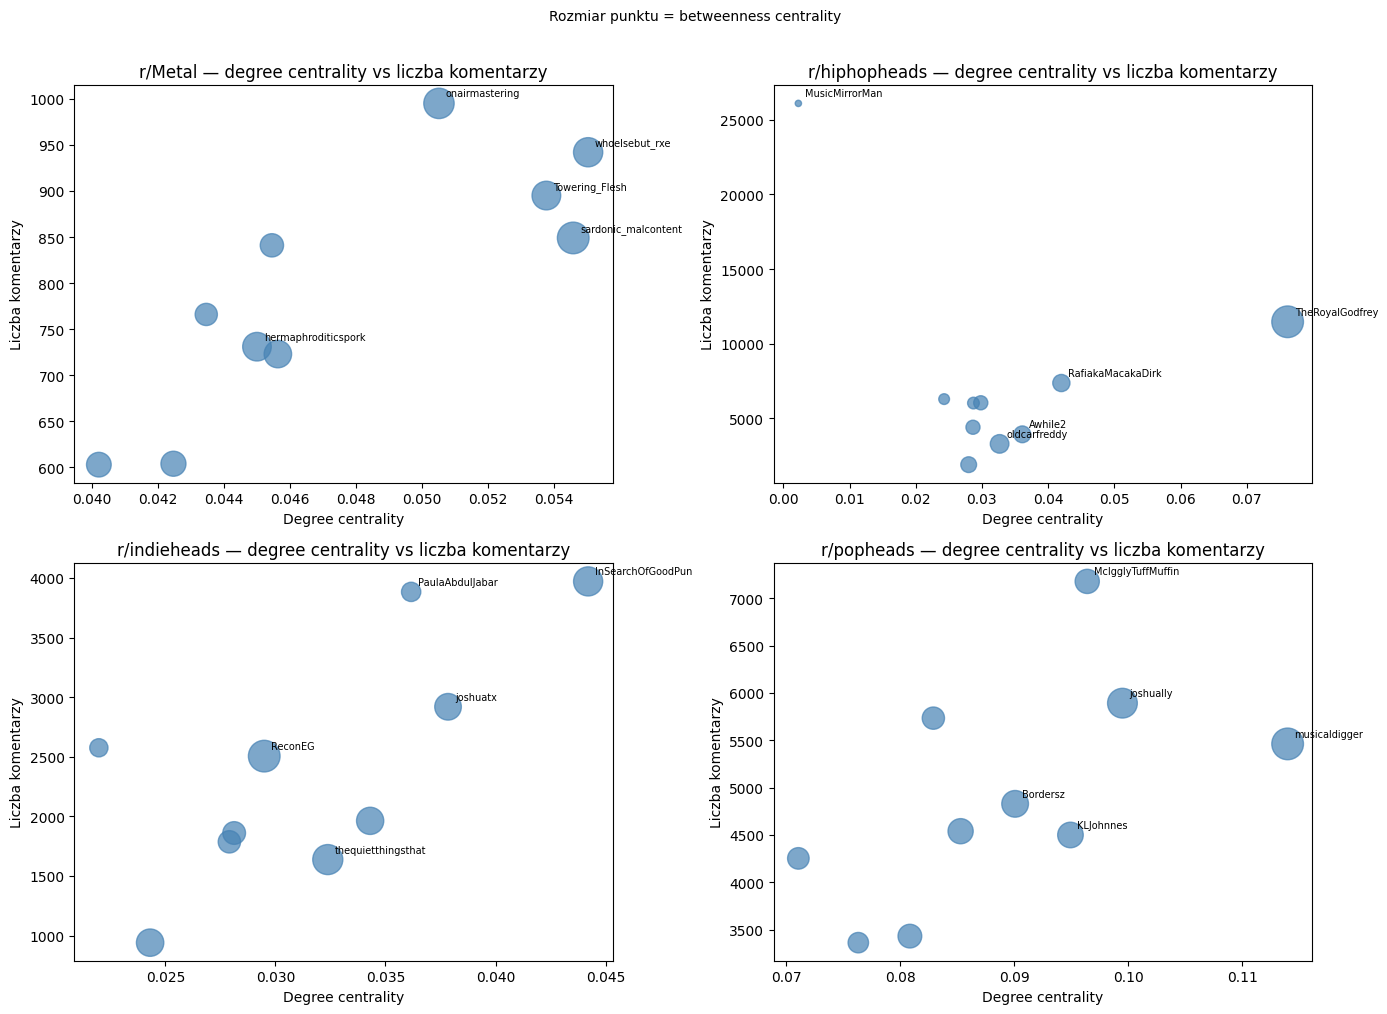

In [16]:
# scatter: degree centrality vs liczba komentarzy, rozmiar punktu = betweenness
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, sub_df in enumerate(all_influence):
    sub = sub_df['subreddit'].iloc[0]
    ax = axes[i]
    ax.scatter(sub_df['degree_centrality'], sub_df['comment_count'],
               s=sub_df['betweenness_centrality_norm'] * 500 + 20, alpha=0.7, color='steelblue')
    for user, row in sub_df.nlargest(5, 'influence_score').iterrows():
        ax.annotate(user, (row['degree_centrality'], row['comment_count']),
                    textcoords='offset points', xytext=(5, 5), fontsize=7)
    ax.set_title(f'r/{sub} — degree centrality vs liczba komentarzy')
    ax.set_xlabel('Degree centrality')
    ax.set_ylabel('Liczba komentarzy')
plt.suptitle('Rozmiar punktu = betweenness centrality', y=1.01, fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/figures/influencers_scatter.png', dpi=150)
plt.show()

## Wnioski

*(uzupełnij po uruchomieniu)*

- ...
- ...
- ...